In [1]:
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

# Настройки отображения
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

# Путь к данным (ноутбук лежит в notebooks/, поэтому ../)
DATA_ROOT = Path('../data/MVTecAD/bottle')
print('Датасет:', DATA_ROOT.resolve())
print('Существует:', DATA_ROOT.exists())

Датасет: C:\MyPythonProjects\defect-detection\data\MVTecAD\bottle
Существует: True


In [2]:
# Собираем статистику по всем папкам
splits = {
    'train/good': DATA_ROOT / 'train' / 'good',
    'test/good': DATA_ROOT / 'test' / 'good',
}

# Добавляем все папки с дефектами из test/
test_dir = DATA_ROOT / 'test'
for defect_dir in sorted(test_dir.iterdir()):
    if defect_dir.is_dir() and defect_dir.name != 'good':
        splits[f'test/{defect_dir.name}'] = defect_dir

# Считаем количество файлов
stats = []
for name, path in splits.items():
    files = list(path.glob('*.png'))
    stats.append({
        'split': name,
        'count': len(files),
    })

df = pd.DataFrame(stats)
print(df.to_string(index=False))
print(f'\nВсего изображений: {df["count"].sum()}')

             split  count
        train/good    209
         test/good     20
 test/broken_large     20
 test/broken_small     22
test/contamination     21

Всего изображений: 292


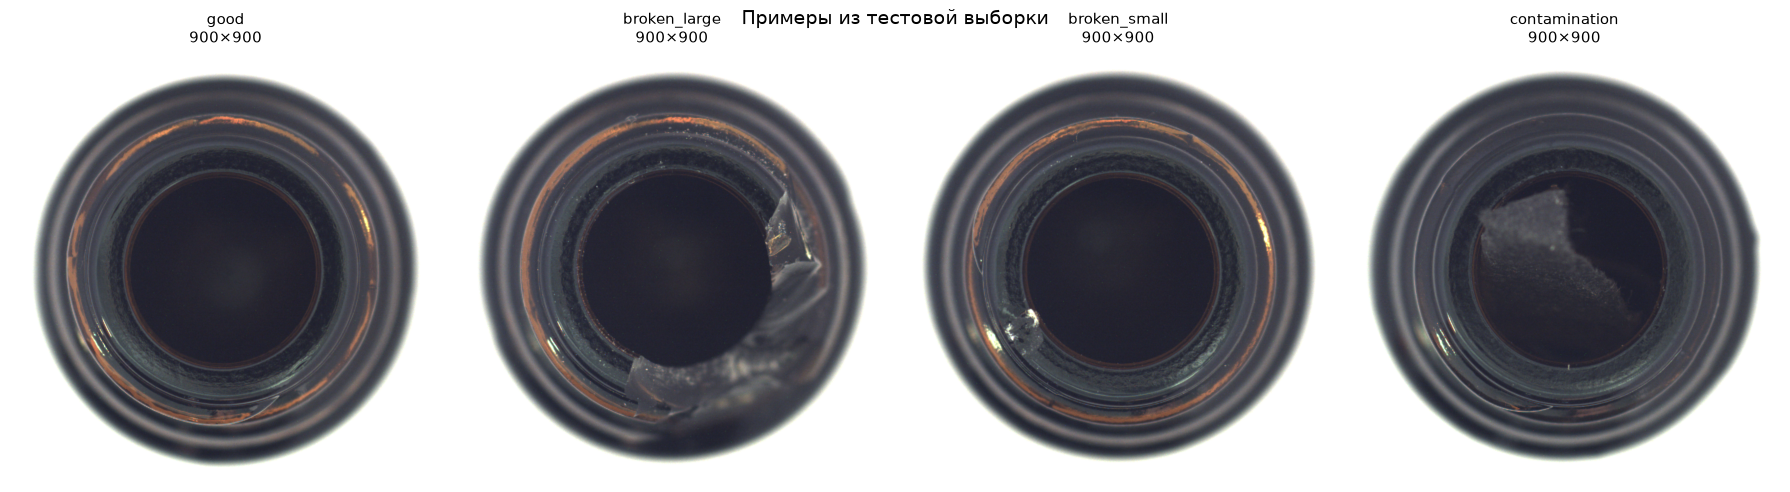

In [3]:
# Показать по одному примеру из каждой категории
categories = ['good', 'broken_large', 'broken_small', 'contamination']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, cat in zip(axes, categories):
    path = DATA_ROOT / 'test' / cat
    img_path = sorted(path.glob('*.png'))[0]
    img = Image.open(img_path)
    
    ax.imshow(img)
    ax.set_title(f'{cat}\n{img.size[0]}×{img.size[1]}', fontsize=11)
    ax.axis('off')

plt.suptitle('Примеры из тестовой выборки', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# Проверить, все ли изображения одного размера
sizes = []
for img_path in (DATA_ROOT / 'train' / 'good').glob('*.png'):
    with Image.open(img_path) as img:
        sizes.append(img.size)

size_counter = Counter(sizes)
print('Уникальные размеры:')
for size, count in size_counter.most_common():
    print(f'  {size[0]}×{size[1]}: {count} изображений')

Уникальные размеры:
  900×900: 209 изображений


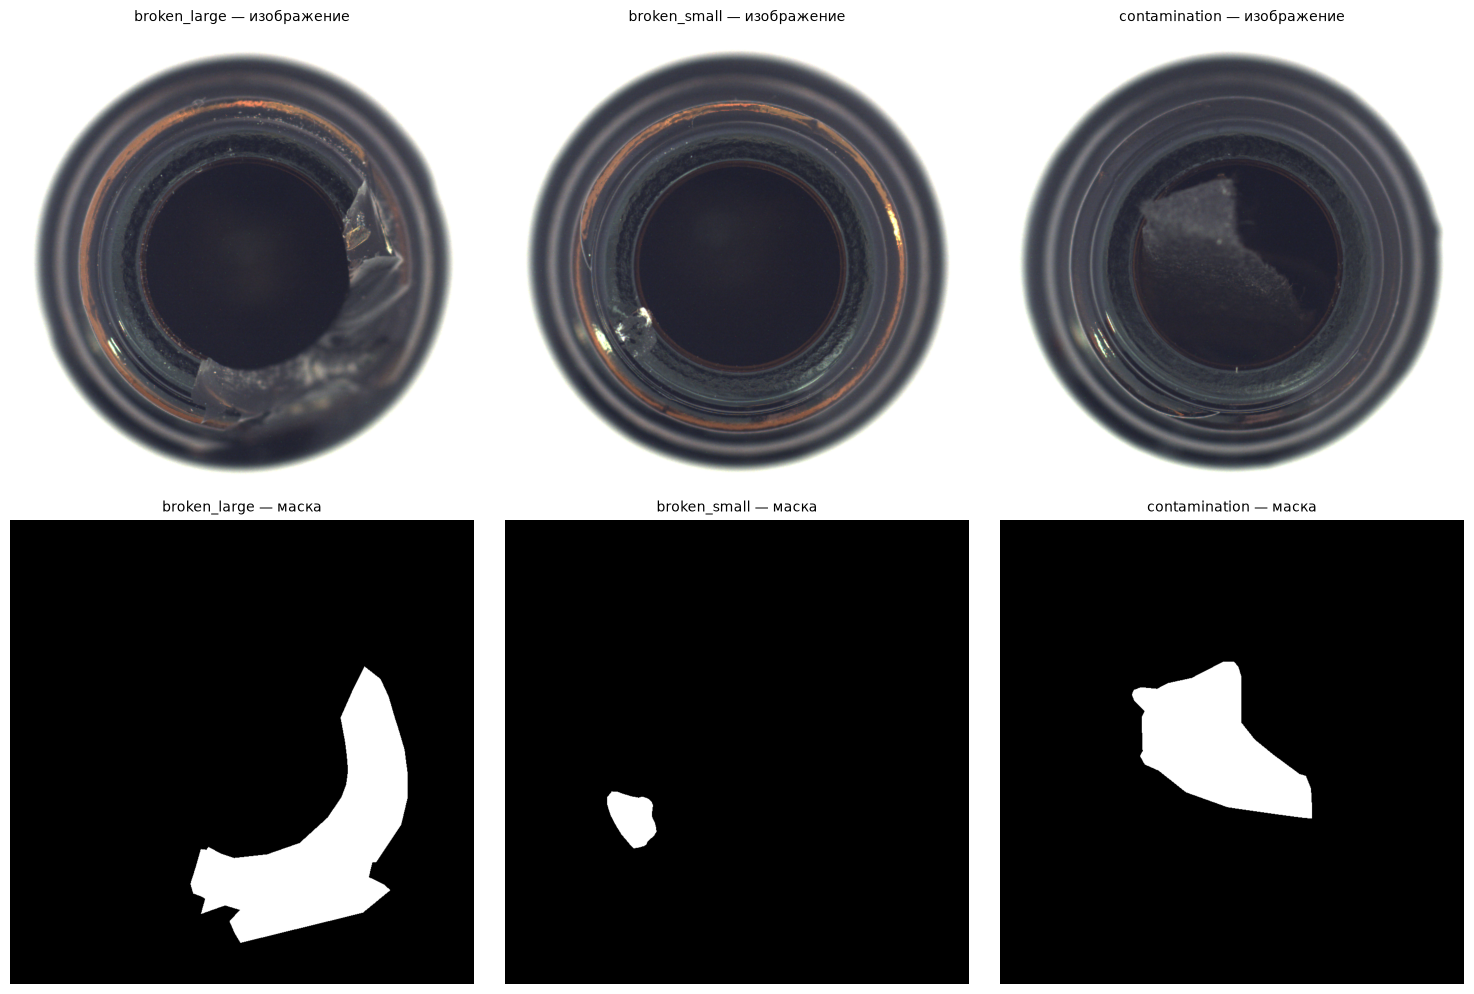

In [5]:
# Показать дефектное изображение + его маску
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col, defect in enumerate(['broken_large', 'broken_small', 'contamination']):
    # Дефектное изображение
    img_path = sorted((DATA_ROOT / 'test' / defect).glob('*.png'))[0]
    img = np.array(Image.open(img_path))
    
    # Соответствующая маска
    mask_path = DATA_ROOT / 'ground_truth' / defect / f'{img_path.stem}_mask.png'
    mask = np.array(Image.open(mask_path))
    
    # Показать изображение
    axes[0, col].imshow(img)
    axes[0, col].set_title(f'{defect} — изображение', fontsize=10)
    axes[0, col].axis('off')
    
    # Показать маску
    axes[1, col].imshow(mask, cmap='gray')
    axes[1, col].set_title(f'{defect} — маска', fontsize=10)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Какую площадь занимает дефект?
defect_ratios = []
for defect in ['broken_large', 'broken_small', 'contamination']:
    mask_dir = DATA_ROOT / 'ground_truth' / defect
    for mask_path in mask_dir.glob('*.png'):
        mask = np.array(Image.open(mask_path))
        ratio = (mask > 0).mean()  # доля пикселей дефекта
        defect_ratios.append({'defect': defect, 'ratio': ratio})

df_ratios = pd.DataFrame(defect_ratios)

# Статистика по каждой категории
summary = df_ratios.groupby('defect')['ratio'].agg(['count', 'mean', 'min', 'max']).round(4)
print(summary)
print(f'\nСредняя доля дефекта: {df_ratios["ratio"].mean():.2%}')

               count    mean     min     max
defect                                      
broken_large      20  0.1170  0.0409  0.2742
broken_small      22  0.0307  0.0088  0.0806
contamination     21  0.0849  0.0058  0.1653

Средняя доля дефекта: 7.62%


In [8]:
# Сохранить сводку в CSV для README
summary.to_csv('../docs/eda_summary.csv')
print('Сохранено: docs/eda_summary.csv')

# Сводная таблица по количеству
df.to_csv('../docs/eda_counts.csv', index=False)
print('Сохранено: docs/eda_counts.csv')

Сохранено: docs/eda_summary.csv
Сохранено: docs/eda_counts.csv
